
# Optical Character Recognition (OCR)
- Basics of OCR techniques
- Text detection and extraction
- OCR libraries and applications

!["OCR overview"](../assets/reference_images/ocr_overview.png)

## 1. Image Preprocessing:
- Grayscale Conversion: Convert the image to grayscale. This simplifies the image data to a single channel and can enhance text features.

- Thresholding:
    Apply thresholding to create a binary image, separating text from the background. This helps in distinguishing text more clearly.
    
- Noise Reduction:
    Use techniques like blurring or morphological operations (erosion and dilation) to remove noise, enhancing the text's clarity.

## 2. Text Detection:
- Contour Detection:
    Find contours in the processed image. Text regions often form distinct contours due to their contrast with the background.

- Bounding Boxes:
    Create bounding boxes around these detected text regions. These boxes enclose the text areas, enabling extraction.

## 3. Text Extraction:
- Extract Text Regions:
    Crop the regions defined by the bounding boxes to focus only on the text areas.
## 4. Optical Character Recognition:
- Apply OCR:
     Use pattern recognition algorithms or libraries like custom implementations of neural networks or more commonly, Tesseract OCR (as mentioned previously) to recognize text within the cropped regions.

## 5. Steps FlowChart:
!["FlowChart OCR"](../assets/reference_images/ocr_flowchart.png)




https://www.v7labs.com/blog/ocr-guide


## install pytesseract

https://medium.com/@BH_Chinmay/installation-of-tesseract-in-python-77daf712420f

In [1]:
! pip install pytesseract


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import pytesseract
import numpy as np
import matplotlib.pyplot as plt
import shutil, os

# Point pytesseract at the Tesseract binary if it isn't already on PATH
if shutil.which("tesseract") is None:
    _default_tesseract = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
    if os.path.exists(_default_tesseract):
        pytesseract.pytesseract.tesseract_cmd = _default_tesseract

def show(img, title=None):
    """Display a BGR/grayscale OpenCV image inline with matplotlib (safe for unattended execution)."""
    if img is None:
        print(f"[{title}] no image to display")
        return
    display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
    cmap = None if img.ndim == 3 else 'gray'
    plt.figure()
    plt.imshow(display_img, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


In [3]:
# load the input image from disk, convert it to grayscale, and blur
# it to reduce noise
path = "./imgs/logo.png"
image = cv2.imread(path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

Convert

R



(C

()



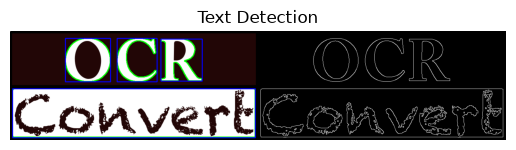

In [4]:
# Apply Canny edge detection
edges = cv2.Canny(blurred, 60, 150)  # Adjust thresholds for optimal edge detection

# Find contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw edges and contours on the original image
cv2.drawContours(image, contours, -1, (0, 255, 0), 2)  # Draw contours in green color
image_with_edges = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)  # Convert edges to 3-channel for display
result_image = cv2.hconcat([image, image_with_edges])  # Combine original image with edges

# Extract text regions using bounding boxes
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(result_image, (x, y), (x + w, y + h), (255, 0, 0), 2)  # Draw bounding boxes in blue
    text_region = image[y:y + h, x:x + w]

    # Apply OCR on text regions
    text = pytesseract.image_to_string(text_region, lang='eng', config='--psm 6')
    print(text)

# Show the resulting image with edges, contours, and bounding boxes
show(result_image, "Text Detection")

## in deep learning detect text 
https://medium.com/technovators/scene-text-detection-in-python-with-east-and-craft-cbe03dda35d5

In [5]:
import math

orig = image.copy()
(H, W) = image.shape[:2]

# The EAST text detector requires both the width and height of the input
# image to be multiples of 32, so resize to the nearest such size and keep
# the scale ratios to map detections back onto the original image
newW = max(32, (W // 32) * 32)
newH = max(32, (H // 32) * 32)
rW = W / float(newW)
rH = H / float(newH)
resized = cv2.resize(image, (newW, newH))

# Define the EAST text detector's parameters
net = cv2.dnn.readNet("model/frozen_east_text_detection.pb")  # Path to the pre-trained EAST text detector
layer_names = [
    "feature_fusion/Conv_7/Sigmoid",
    "feature_fusion/concat_3"
]

# Prepare the image for EAST text detection
blob = cv2.dnn.blobFromImage(resized, 1.0, (newW, newH), (123.68, 116.78, 103.94), swapRB=True, crop=False)
net.setInput(blob)
(scores, geometry) = net.forward(layer_names)

# Set minimum confidence level and apply non-maxima suppression to get the text bounding boxes
min_confidence = 0.5  # Adjust this threshold for different images
boxes = []
confidences = []
for y in range(scores.shape[2]):
    scores_data = scores[0, 0, y]
    x_data0 = geometry[0, 0, y]
    x_data1 = geometry[0, 1, y]
    x_data2 = geometry[0, 2, y]
    x_data3 = geometry[0, 3, y]
    angles_data = geometry[0, 4, y]

    for x in range(scores.shape[3]):
        if scores_data[x] < min_confidence:
            continue

        # Calculate offset factor as the corresponding feature map point
        (offsetX, offsetY) = (x * 4.0, y * 4.0)

        # Extract the rotation angle for the prediction
        angle = angles_data[x]
        cos = np.cos(angle)
        sin = np.sin(angle)

        # Calculate the width and height of the bounding box
        h = x_data0[x] + x_data2[x]
        w = x_data1[x] + x_data3[x]

        # Compute the rotated box's two corner offsets and its center,
        # as required by cv2.dnn.NMSBoxesRotated (center, (w, h), angle_in_degrees)
        end_x = offsetX + (cos * x_data1[x]) + (sin * x_data2[x])
        end_y = offsetY - (sin * x_data1[x]) + (cos * x_data2[x])
        p1 = (end_x - h * sin, end_y - h * cos)
        p3 = (end_x - w * cos, end_y + w * sin)
        center = (0.5 * (p1[0] + p3[0]), 0.5 * (p1[1] + p3[1]))

        boxes.append((center, (float(w), float(h)), -angle * 180.0 / math.pi))
        confidences.append(float(scores_data[x]))

# Apply non-maxima suppression to suppress weak, overlapping bounding boxes
indices = cv2.dnn.NMSBoxesRotated(boxes, confidences, min_confidence, 0.4)

# Loop over the indices and extract text regions for OCR
for i in indices:
    i = int(i[0]) if hasattr(i, '__len__') else int(i)
    (center, size, angle) = boxes[i]

    # Scale the center/size back to the original image size
    center = (center[0] * rW, center[1] * rH)
    size = (max(size[0] * rW, 1), max(size[1] * rH, 1))

    # Rotate the bounding box and extract the text region
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(orig, M, orig.shape[1::-1], flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    cropped = cv2.getRectSubPix(rotated, (int(round(size[0])), int(round(size[1]))), center)

    # Apply OCR on the text region using Tesseract
    text = pytesseract.image_to_string(cropped, config='--psm 7')
    print("Detected Text:", text)

Detected Text: ICR

Detected Text: Paling

